# Deep Neural Networks

In [275]:
import numpy as np
import matplotlib.pyplot as plt
import struct

images_path = 'data/mnist-handwritten-images/train-images.idx3-ubyte'
labels_path = 'data/mnist-handwritten-images/train-labels.idx1-ubyte'

def load_images(images_path, labels_path):
    with open(images_path,'rb') as f:
        _ , size = struct.unpack(">II", f.read(8))
        nrows, ncols = struct.unpack(">II", f.read(8))
        images = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
        images = images.reshape((size, nrows, ncols))

    with open(labels_path,'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
        labels = labels.reshape((size,))

    return images, labels

X, y = load_images(images_path, labels_path)

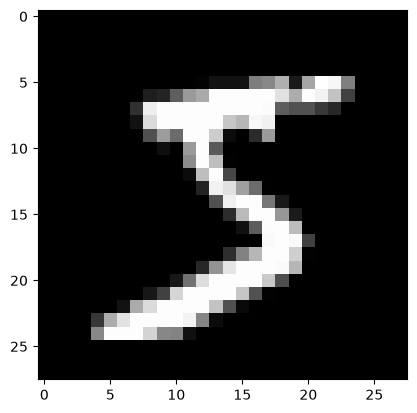

In [207]:
plt.imshow(X[0,:,:], cmap="gray")
plt.show()

In [276]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

y_train_enc = OneHotEncoder(sparse_output=False).fit_transform(y[:10000,np.newaxis])

In [280]:
rng = np.random.default_rng()
X_train = StandardScaler().fit_transform(X[:10000,:,:].reshape(10000,28*28)).T
X_test = StandardScaler().fit_transform(X[10000:11000,:,:].reshape(1000,28*28)).T
y_train = y_train_enc.T
y_test = y[10000:11000,np.newaxis].T

In [281]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((784, 10000), (10, 10000), (784, 1000), (1, 1000))

In [182]:
def linear_forward(a,w,b):
    """
    a - (n,m) array
    w - (l,n) array
    b - (l,1) array
    """
    return w @ a + b

def relu_forward(z):
    return np.maximum(0,z)

def softmax_forward(z):
    return (1/np.sum(np.exp(z),axis=0))*np.exp(z)

a = rng.normal(size=(3,4))
w = rng.normal(size=(5,3))
b = rng.normal(size=(5,1))

print(linear_forward(a,w,b))

[[-0.90604164  4.02570234 -4.51929314 -4.05915975]
 [ 0.62636047 -2.50380038  2.4884518   2.831921  ]
 [-0.91307044  0.64404474 -0.04722733 -0.31509305]
 [-0.40293789  1.32922812 -1.31012922 -2.1423738 ]
 [-0.19434236  2.05701177 -1.33250197 -2.24383835]]


In [183]:
z = rng.normal(size=(3,3))
print(z)

[[-0.84779861  1.73112762 -0.84470283]
 [-0.13884439  0.07304945  1.60825619]
 [ 0.65463124 -1.09581211 -0.8517438 ]]


In [184]:
print(f'{relu_forward(z)}\n\n{softmax_forward(z)}')

[[0.         1.73112762 0.        ]
 [0.         0.07304945 1.60825619]
 [0.65463124 0.         0.        ]]

[[0.13289995 0.80019302 0.07344478]
 [0.27003479 0.15244057 0.85362575]
 [0.59706526 0.04736641 0.07292947]]


In [185]:
def linear_relu_backward(da,cache):
    """
    da - (n,m) array
    cache - forward cache containing w,z,a,activation
    """
    _,_,z,_,_ = cache
    dz = da * np.where(z>0,1,0)
    return dz

def linear_softmax_backward(da,cache):
    """
    da - (n,m) array
    cache - forward cache containing z,a (both n,m arrays)
    """
    _,_,z,a,_ = cache
    dz = a * (da - np.sum(da * a, axis=0))
    return dz

z1 = linear_forward(a,w,b)
a1 = softmax_forward(z1)
w2 = rng.normal(size=(10,len(a1)))
b2 = rng.normal(size=(10,1))
z2 = linear_forward(a1,w2,b2)
a2 = softmax_forward(z2)

y = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
])

dz2 = (1/a2.shape[1]) * (a2 - y)
da1 = w2.T @ dz2
dz1 = linear_softmax_backward(da1,(w,b,z1,a1,"softmax"))
dz1

array([[-0.04333246,  0.06809086, -0.00070743, -0.00015987],
       [-0.02363736, -0.00039296,  0.02267131,  0.00804691],
       [ 0.01401989, -0.01445133, -0.00694028, -0.00508631],
       [ 0.02701868, -0.0304355 , -0.01071683, -0.00197113],
       [ 0.02593126, -0.02281107, -0.00430677, -0.0008296 ]])

In [234]:
def cost_function(a,y):
    """
    a - (n,m) array containing n probabilities for each sample m
    y - (n,m) ground truth labels - 1-of-K encoded
    """
    sum_1 = np.sum(y * np.log(a), axis=0, keepdims=True)
    sum_2 = np.sum(sum_1, axis=1)
    return -np.squeeze(sum_2)/y.shape[1]

a = np.array([
    [0.86, 0.02, 0.4],
    [0.20, 0.60, 0.1],
    [0.40, 0.34, 0.7]
])

y = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

print(cost_function(a,y))

0.33944115247976897


In [235]:
def initialize_params(layer_dims):
    parameters = []
    for l in range(1,len(layer_dims)):
        w = rng.normal(size=(layer_dims[l],
                             layer_dims[l-1]
                            )) * 0.01
        b = np.zeros(shape=(layer_dims[l],1))
        parameters.append((w,b))
    return parameters

parameters = initialize_params([700,10,30,20,10])   
for i,param in enumerate(parameters):
    w,b = param
    print(f"Layer {i}: {w.shape}, {b.shape}")

Layer 0: (10, 700), (10, 1)
Layer 1: (30, 10), (30, 1)
Layer 2: (20, 30), (20, 1)
Layer 3: (10, 20), (10, 1)


In [249]:
def deep_forward(X, parameters, activations):
    w1,b1 = parameters[0]
    activation1 = activations[0]
    z1 = linear_forward(X,w1,b1)
    a1 = relu_forward(z1) if activation1=='relu' else softmax_forward(z1)
    
    caches = [(w1,b1,z1,a1,activation1)] #cache z and a
    for param,activation in zip(parameters[1:],activations[1:]):
        w,b = param
        z = linear_forward(caches[-1][3],w,b)
        a = relu_forward(z) if activation=='relu' else softmax_forward(z)
        caches.append((w,b,z,a,activation))

    return caches

In [250]:
# Layer 0 -> Layer 1 [ReLu] -> Layer 2 [Softmax] -> Layer 3 [ReLU]-> Output Layer [Softmax]
X = rng.normal(size=(700,1200))
y = rng.normal(size=(10,1200))
layers = [('relu',10),('softmax',30),('relu',20)]
layer_dims = [700,10,30,20,10]
parameters = initialize_params(layer_dims)
activations = ['relu', 'softmax', 'relu', 'softmax']
caches = deep_forward(X,parameters,activations)

for i,cache in enumerate(caches):
    w,b,z,a,activation = cache
    print(f"Layer {i+1}: {w.shape}, {z.shape}, {a.shape}, {activation}")

Layer 1: (10, 700), (10, 1200), (10, 1200), relu
Layer 2: (30, 10), (30, 1200), (30, 1200), softmax
Layer 3: (20, 30), (20, 1200), (20, 1200), relu
Layer 4: (10, 20), (10, 1200), (10, 1200), softmax


In [251]:
for i,cache in enumerate(caches[:-1][::-1]):
    w,b,z,a,_ = cache
    print(f"Layer {i+1}: {w.shape}, {z.shape}, {a.shape}")

Layer 1: (20, 30), (20, 1200), (20, 1200)
Layer 2: (30, 10), (30, 1200), (30, 1200)
Layer 3: (10, 700), (10, 1200), (10, 1200)


In [244]:
def deep_backward(X, y, caches):
    m = X.shape[1]
    L = len(caches)
    wL,bL,zL,aL,_ = caches[-1]
    dzL = (1/m)*(aL - y)
    da_prev = wL.T @ dzL
    a_prev = caches[-2][3] if L > 1 else X
    dwL = dzL @ a_prev.T
    dbL = np.sum(dzL,axis=1,keepdims=True)
    grads = [(dwL,dbL)]
    for l in reversed(range(L-1)):
        cache = caches[l]
        w, b, z, a, activation = cache
        da = da_prev
        dz = linear_relu_backward(da,cache) if activation=="relu" else linear_softmax_backward(da,cache)
        da_prev = w.T @ dz
        a_prev = caches[l-1][3] if l>0 else X
        dw = dz @ a_prev.T
        db = np.sum(dz,axis=1,keepdims=True)
        grads.append((dw,db))

    return grads[::-1]

In [245]:
grads = deep_backward(X, y, caches)
for i,grad in enumerate(grads):
    dw,db = grad
    w,b,z,a,activation = caches[i]
    print(f"Layer {i+1}: w:{w.shape}, dw:{dw.shape}, b:{b.shape}, db:{db.shape}")

Layer 1: w:(10, 700), dw:(10, 700), b:(10, 1), db:(10, 1)
Layer 2: w:(30, 10), dw:(30, 10), b:(30, 1), db:(30, 1)
Layer 3: w:(20, 30), dw:(20, 30), b:(20, 1), db:(20, 1)
Layer 4: w:(10, 20), dw:(10, 20), b:(10, 1), db:(10, 1)


In [246]:
def update_parameters(parameters, grads, learning_rate):
    upd_params = []
    for param,grad in zip(parameters,grads):
        w,b = param
        dw,db = grad
        w -= learning_rate * dw
        b -= learning_rate * db
        upd_params.append((w,b))
    return upd_params

In [272]:
from tqdm import tqdm

def train_network(X,y,layers,learning_rate=0.1,max_iter=1000,tol=1e-3):
    """
    layers - list of tuples (n_nodes,activation). n_nodes is the number of nodes of the hidden layer, activation is either "relu" or "softmax"
    training labels y must be one-hot-encoded
    """
    layer_dims = [X.shape[0]]
    activations = []
    for size,activation in layers:
        layer_dims.append(size)
        activations.append(activation)

    layer_dims.append(y.shape[0])
    activations.append("softmax")
    print(layer_dims)
    print(activations)

    parameters = initialize_params(layer_dims)
    pbar = tqdm(range(max_iter))
    for i in pbar:
        forward_cache = deep_forward(X, parameters, activations)
        _,_,_,a,_ = forward_cache[-1]
        loss = cost_function(a,y)

        if i % int(10) == 0:
            pbar.set_postfix({'loss': loss})
        
        if abs(loss) < tol:
            return {'parameters': parameters, 'activations': activations}
        grads = deep_backward(X,y,forward_cache)
        parameters = update_parameters(parameters, grads, learning_rate)
    print(f"Warning: maximum number of iterations reached - loss={loss}")
    return {'parameters': parameters, 'activations': activations}

def predict_proba(X,parameters,activations):
    a = deep_forward(X,parameters,activations)[-1][3]
    return a

def predict(X,parameters,activations):
    a = predict_proba(X,parameters,activations)
    pred = np.argmax(a,axis=0,keepdims=True)
    return pred

In [265]:
layers = [(128,"relu"),(64,"relu")]
results = train_network(X_train,y_train,layers,max_iter=6000,learning_rate=0.15)

[784, 128, 64, 10]
['relu', 'relu', 'softmax']


 71%|█████████████████████████████████████████████████▊                    | 4271/6000 [02:11<00:53, 32.46it/s, loss=0.001]


In [268]:
for param in results['parameters']:
    w,b = param
    print(f"w: {w.shape}, b: {b.shape}")

w: (128, 784), b: (128, 1)
w: (64, 128), b: (64, 1)
w: (10, 64), b: (10, 1)


In [284]:
from sklearn.metrics import accuracy_score
ypred = predict(X_test, results['parameters'], results['activations'])
print("Accuracy Score: {:.2%}".format(accuracy_score(y_test.T,ypred.T)))

Accuracy Score: 95.60%
